# prog16 — 16 programming tasks × 3 conditions, Claude Code

**Run:** `prog16-*`, executed 2026-08-27. **Data:** `jobs/prog16-*/` (raw), read here
through `src/prog16_extract.py`.

| | |
|---|---|
| Agent | `claude-code` (Claude Code 2.1.247), model `claude-sonnet-5` |
| Conditions | `baseline` (task only), `sdd` (SDD toolkit as shipped), `codezen-viable` (4-skill CodeZen subset) |
| Tasks | the 16 ids in `config/tasks-programming.txt` — `software-engineering` and `debugging` only |
| Attempts | **1 per cell** — 16 × 3 × 1 = 48 trials. The design in `TODO.md` called for 2; the run recorded 1 |
| Cost | $75.49 of model spend, 11.8 h of agent wall-clock |

Two things this notebook does that `results/prog16_report.md` does not:

1. It goes back to the raw trial artefacts, so it can use the verifier's **per-test**
   results, the trajectory's **per-step** tokens and tool calls, and the trial's
   **phase timestamps** — none of which survive into the aggregated report.
2. It separates *what the outcome was* from *whether this design could have measured
   an outcome at all*. That second question turns out to dominate the reading.

Figures are written to `figures/` as 300 dpi PNG and as SVG, sized for a 16:9 slide.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

ANALYSIS_DIR = Path.cwd() if Path.cwd().name == "analysis" else Path("results/analysis")
REPO_ROOT = ANALYSIS_DIR.parents[1]
DATA_DIR = ANALYSIS_DIR / "data"
FIG_DIR = ANALYSIS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ANALYSIS_DIR / "src"))

# Re-derive the tidy tables from jobs/ when they are missing or older than the extractor.
extractor = ANALYSIS_DIR / "src" / "prog16_extract.py"
trials_csv = DATA_DIR / "prog16_trials.csv"
if not trials_csv.is_file() or trials_csv.stat().st_mtime < extractor.stat().st_mtime:
    subprocess.run([sys.executable, str(extractor)], check=True, cwd=REPO_ROOT)

trials = pd.read_csv(DATA_DIR / "prog16_trials.csv")
tests = pd.read_csv(DATA_DIR / "prog16_tests.csv")
steps = pd.read_csv(DATA_DIR / "prog16_steps.csv")
calls = pd.read_csv(DATA_DIR / "prog16_tool_calls.csv")

CONDITIONS = ["baseline", "sdd", "codezen-viable"]
LABELS = {"baseline": "baseline", "sdd": "SDD", "codezen-viable": "CodeZen (viable)"}
trials["condition"] = pd.Categorical(trials["condition"], CONDITIONS, ordered=True)

print(f"{len(trials)} trials, {trials.task.nunique()} tasks, {trials.condition.nunique()} conditions")
print(f"total model spend ${trials.cost_usd.sum():,.2f} | agent wall-clock {trials.agent_sec.sum()/3600:.1f} h")
trials[["task", "condition", "reward", "partial_credit", "cost_usd", "agent_sec", "exception_type"]].head()

48 trials, 16 tasks, 3 conditions
total model spend $75.49 | agent wall-clock 11.8 h


,task,condition,reward,partial_credit,cost_usd,agent_sec,exception_type
0,build-cython-ext,baseline,1.0,1.0,0.773043,288.952107,NaN
1,build-pmars,baseline,1.0,1.0,0.306802,107.602066,NaN
2,cancel-async-tasks,baseline,1.0,1.0,0.469594,247.173616,NaN
3,circuit-fibsqrt,baseline,1.0,1.0,1.527871,1339.406210,NaN
4,custom-memory-heap-crash,baseline,1.0,1.0,1.459103,628.606993,NaN


## 0. Chart style

One palette for the whole deck: categorical slots 1–3 of the validated default palette
(`#2a78d6` blue, `#eb6834` orange, `#1baf7a` aqua) assigned to the three conditions and
never reassigned, so a colour means the same condition in every figure. Pass/fail state
uses the reserved status colours and always carries a glyph as well, never colour alone.

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"

# Categorical identity: fixed slot order, never cycled, never re-assigned on filtering.
COLOR = {"baseline": "#2a78d6", "sdd": "#eb6834", "codezen-viable": "#1baf7a"}
# Reserved status palette — state, not identity. Always shipped with a glyph or label.
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"
# One-hue ordinal ramp (blue), no step lighter than 250 on a light surface.
BLUE_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": ["DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.titlepad": 12,
    "axes.labelsize": 12,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS,
    "axes.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
    "legend.fontsize": 11,
    "legend.labelcolor": INK_2,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "figure.dpi": 120,
    # A dollar sign in a label must render as a dollar sign, not open mathtext.
    "text.parse_math": False,
})


def bare(ax, grid_axis="y"):
    # Hairline recessive chrome: no top/right spines, solid hairline grid on one axis.
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    if grid_axis:
        ax.grid(True, axis=grid_axis, zorder=0)
        ax.set_axisbelow(True)
    return ax


def titled(ax, title, sub=None):
    # Title on its own line with room for an optional subtitle underneath it.
    ax.set_title(title, loc="left", pad=30 if sub else 12)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=10.5, color=MUTED,
                va="bottom")


def spread_labels(ax, points, min_gap_frac=0.062):
    # Direct labels at the right edge, pushed apart so they cannot collide.
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * min_gap_frac
    placed = []
    for x, y, text, color in sorted(points, key=lambda p: p[1]):
        if placed and y - placed[-1] < gap:
            y = placed[-1] + gap
        placed.append(y)
        ax.annotate(text, (x, y), xytext=(6, 0), textcoords="offset points", va="center",
                    fontsize=10.5, color=color, fontweight="bold")


def save(fig, name, note=None):
    # Write one figure twice: 300 dpi PNG for slides, SVG for editing.
    if note:
        fig.text(0.01, 0.005, note, ha="left", va="bottom", fontsize=9, color=MUTED)
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.svg", bbox_inches="tight")
    print(f"figures/{name}.png  figures/{name}.svg")


def wilson(k, n, z=1.96):
    # Wilson score interval: the honest interval for a rate at n = 16.
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

## 1. The headline: no outcome difference

Three views of "did it work", from coarsest to finest.

- **Success rate** — the benchmark's own binary reward, 1.0 or nothing.
- **Partial credit** — the fraction of the verifier's individual tests that passed,
  read from `verifier/ctrf.json`. This is a strictly finer measurement of the same
  trial and it is free: 183 test outcomes instead of 48 binary ones.
- **Test-level pass rate** — the same test outcomes pooled, which is what a
  test-level model would use.

In [3]:
summary = (
    trials.groupby("condition", observed=True)
    .agg(
        trials=("task", "size"),
        successes=("success", "sum"),
        success_rate=("success", "mean"),
        partial_credit=("partial_credit", "mean"),
        cost_usd=("cost_usd", "sum"),
        cost_per_trial=("cost_usd", "mean"),
        agent_sec=("agent_sec", "mean"),
        budget_used=("budget_used", "mean"),
        output_tokens=("output_tokens", "mean"),
        steps=("n_steps", "mean"),
        tool_calls=("n_tool_calls", "mean"),
        agent_timeouts=("agent_timeout", "sum"),
        skill_calls=("n_toolkit_skill_calls", "sum"),
    )
    .assign(cost_per_success=lambda d: d.cost_usd / d.successes)
)
summary.round(3)

,trials,successes,success_rate,partial_credit,cost_usd,cost_per_trial,agent_sec,budget_used,output_tokens,steps,tool_calls,agent_timeouts,skill_calls,cost_per_success
condition,,,,,,,,,,,,,,
baseline,16,13,0.812,0.896,19.930,1.246,801.020,0.437,51142.750,27.750,28.688,0,0,1.533
sdd,16,12,0.750,0.844,24.943,1.559,854.279,0.417,58503.812,33.875,34.125,1,6,2.079
codezen-viable,16,13,0.812,0.911,30.615,1.913,994.063,0.564,81835.562,43.375,46.250,4,9,2.355


figures/01-outcome.png  figures/01-outcome.svg


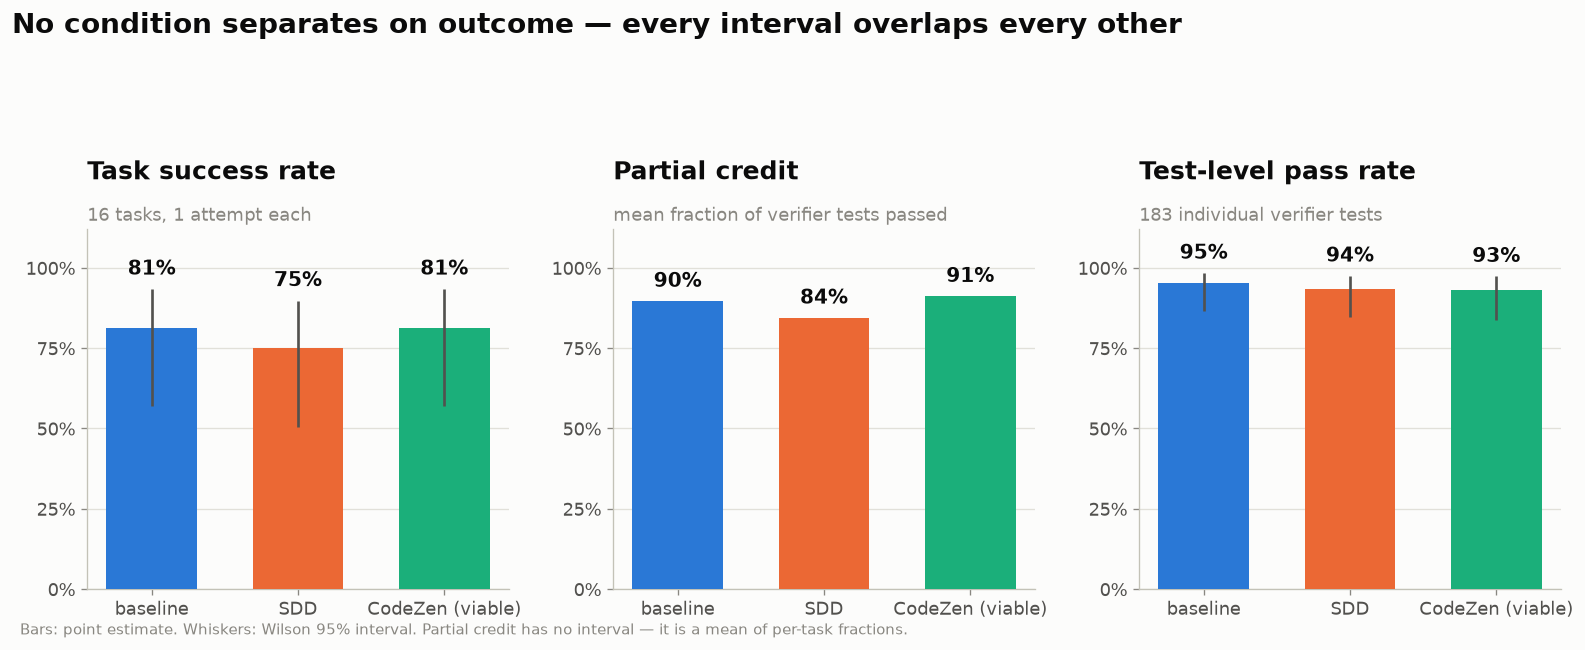

In [4]:
test_pass = (
    tests.assign(passed=lambda d: (d.status == "passed").astype(int))
    .groupby("condition")
    .agg(n_tests=("passed", "size"), pass_rate=("passed", "mean"))
    .reindex(CONDITIONS)
)

fig, axes = plt.subplots(1, 3, figsize=(13.33, 4.6))
panels = [
    ("Task success rate", [summary.loc[c, "success_rate"] for c in CONDITIONS],
     [wilson(summary.loc[c, "successes"], summary.loc[c, "trials"]) for c in CONDITIONS],
     "16 tasks, 1 attempt each"),
    ("Partial credit", [trials.loc[trials.condition == c, "partial_credit"].mean() for c in CONDITIONS],
     None, "mean fraction of verifier tests passed"),
    ("Test-level pass rate", [test_pass.loc[c, "pass_rate"] for c in CONDITIONS],
     [wilson(test_pass.loc[c, "pass_rate"] * test_pass.loc[c, "n_tests"], test_pass.loc[c, "n_tests"])
      for c in CONDITIONS],
     "183 individual verifier tests"),
]

for ax, (title, values, cis, sub) in zip(axes, panels):
    x = np.arange(len(CONDITIONS))
    for i, cond in enumerate(CONDITIONS):
        ax.bar(x[i], values[i], width=0.62, color=COLOR[cond], zorder=3)
        top = max(values[i], cis[i][1] if cis else 0)
        ax.text(x[i], top + 0.03, f"{values[i]*100:.0f}%", ha="center", va="bottom",
                fontsize=12, color=INK, fontweight="bold")
    if cis:
        for i, (lo, hi) in enumerate(cis):
            ax.plot([x[i], x[i]], [lo, hi], color=INK_2, lw=1.6, zorder=4,
                    solid_capstyle="butt")
    bare(ax)
    ax.set_xticks(x, [LABELS[c] for c in CONDITIONS])
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.01, 0.25))
    ax.set_yticklabels([f"{v:.0%}" for v in np.arange(0, 1.01, 0.25)])
    titled(ax, title, sub)

fig.suptitle("No condition separates on outcome — every interval overlaps every other",
             x=0.005, ha="left", fontsize=17, fontweight="bold", color=INK, y=1.14)
fig.tight_layout()
save(fig, "01-outcome", "Bars: point estimate. Whiskers: Wilson 95% interval. Partial credit has no interval — it is a mean of per-task fractions.")
plt.show()

### Paired tests

Every task ran in every condition, so the comparison is paired and the right tests are
exact McNemar on the binary outcome and Wilcoxon signed-rank on the continuous ones.

In [5]:
def mcnemar_exact(a, b):
    # Exact McNemar on paired binary outcomes: only discordant pairs carry information.
    pv = trials.pivot_table(index="task", columns="condition", values="success", observed=True)
    only_a = int(((pv[a] == 1) & (pv[b] == 0)).sum())
    only_b = int(((pv[a] == 0) & (pv[b] == 1)).sum())
    n_disc = only_a + only_b
    p = stats.binomtest(only_b, n_disc, 0.5).pvalue if n_disc else 1.0
    return {"pair": f"{LABELS[a]} vs {LABELS[b]}", f"only {a}": only_a, f"only {b}": only_b,
            "discordant": n_disc, "p": p}


rows = [mcnemar_exact("baseline", "sdd"), mcnemar_exact("baseline", "codezen-viable"),
        mcnemar_exact("sdd", "codezen-viable")]
for r in rows:
    print(f"{r['pair']:<32} discordant pairs = {r['discordant']}   exact McNemar p = {r['p']:.3f}")

print()
pairs = [("baseline", "sdd"), ("baseline", "codezen-viable")]
metric_rows = []
for metric in ["partial_credit", "cost_usd", "agent_sec", "output_tokens", "n_steps",
               "n_tool_calls", "budget_used"]:
    pv = trials.pivot_table(index="task", columns="condition", values=metric, observed=True)
    for a, b in pairs:
        sub = pv[[a, b]].dropna()
        delta = sub[b] - sub[a]
        w = stats.wilcoxon(sub[b], sub[a])
        metric_rows.append({
            "metric": metric, "vs": LABELS[b], "n_pairs": len(sub),
            "median delta": delta.median(), "mean delta": delta.mean(),
            "ratio of totals": sub[b].sum() / sub[a].sum(), "wilcoxon p": w.pvalue,
        })
paired = pd.DataFrame(metric_rows)
paired.round(3)

baseline vs SDD                  discordant pairs = 3   exact McNemar p = 1.000
baseline vs CodeZen (viable)     discordant pairs = 2   exact McNemar p = 1.000
SDD vs CodeZen (viable)          discordant pairs = 5   exact McNemar p = 1.000



,metric,vs,n_pairs,median delta,mean delta,ratio of totals,wilcoxon p
0,partial_credit,SDD,16,0.000,-0.052,0.942,0.593
1,partial_credit,CodeZen (viable),15,0.000,0.000,1.000,1.000
2,cost_usd,SDD,16,0.001,0.313,1.252,0.980
3,cost_usd,CodeZen (viable),16,0.161,0.668,1.536,0.144
4,agent_sec,SDD,16,-50.008,53.259,1.066,0.528
5,agent_sec,CodeZen (viable),16,109.634,193.043,1.241,0.175
6,output_tokens,SDD,16,-2574.500,7361.062,1.144,0.404
7,output_tokens,CodeZen (viable),16,3211.500,30692.812,1.600,0.298
8,n_steps,SDD,16,1.500,6.125,1.221,0.325
9,n_steps,CodeZen (viable),16,4.500,15.625,1.563,0.023


**Read this table before any other.** The only paired comparison that clears p < 0.05
is `n_steps` for CodeZen — the methodology reliably makes the agent take more steps. Every
outcome comparison is flat, and every cost comparison points the same way without reaching
significance at n = 16.

## 2. Could this design have measured anything?

A paired binary comparison learns nothing from a task that both conditions pass or both
fail. Those pairs are *concordant* and drop out of McNemar by construction. So the
effective sample size is not 16 — it is the number of discordant pairs.

figures/02-outcome-matrix.png  figures/02-outcome-matrix.svg


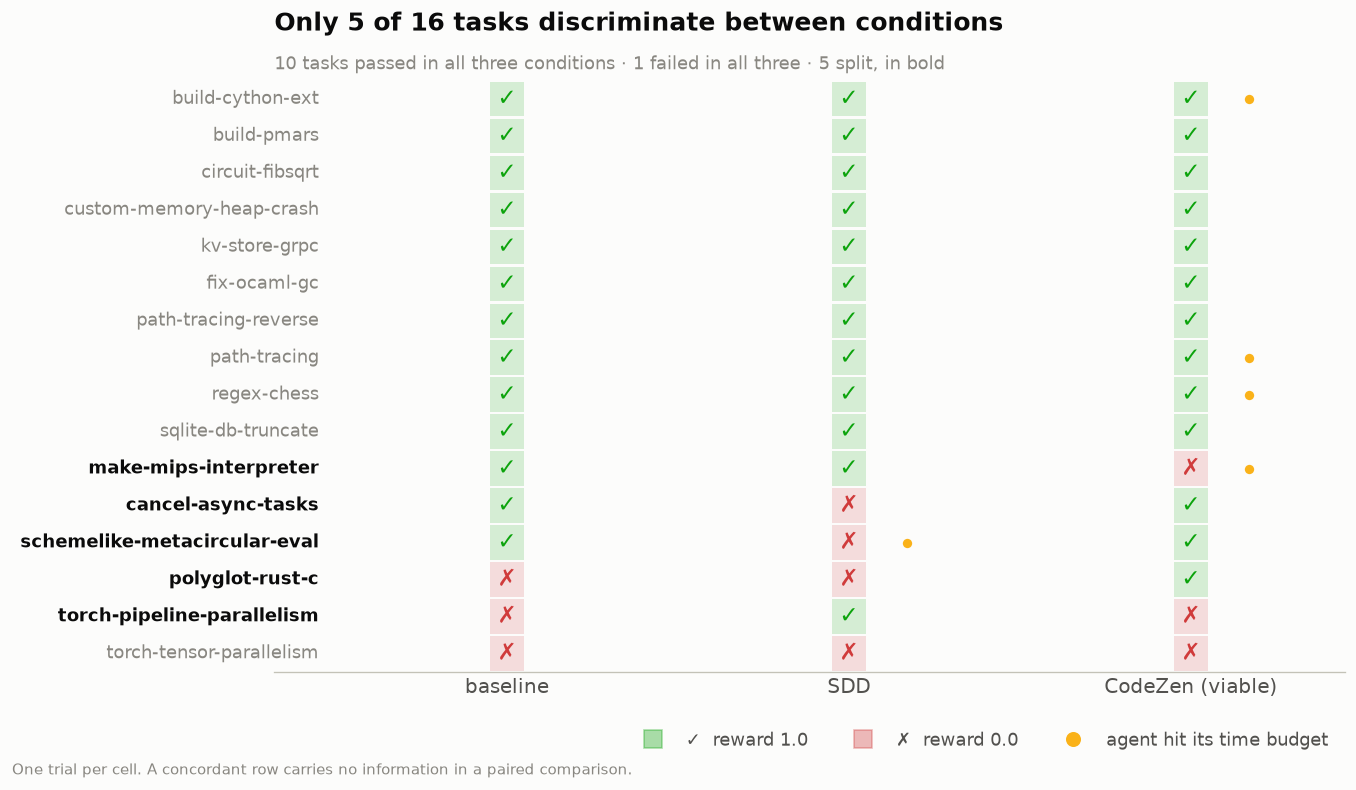

In [6]:
outcome = trials.pivot_table(index="task", columns="condition", values="success", observed=True)
outcome = outcome[CONDITIONS]
timeouts = trials.pivot_table(index="task", columns="condition", values="agent_timeout",
                              observed=True, aggfunc="max")[CONDITIONS]
order = outcome.sum(axis=1).sort_values(ascending=False).index
outcome, timeouts = outcome.loc[order], timeouts.loc[order]

n_all_pass = int((outcome.sum(axis=1) == 3).sum())
n_all_fail = int((outcome.sum(axis=1) == 0).sum())
n_split = len(outcome) - n_all_pass - n_all_fail

fig, ax = plt.subplots(figsize=(11.4, 6.6))
for j, cond in enumerate(CONDITIONS):
    for i, task in enumerate(outcome.index):
        passed = bool(outcome.loc[task, cond])
        color = GOOD if passed else CRITICAL
        ax.scatter(j, i, s=430, marker="s", color=color, alpha=0.16, zorder=2,
                   edgecolors="none")
        ax.text(j, i, "✓" if passed else "✗", ha="center", va="center", fontsize=14,
                color=color, fontweight="bold", zorder=3)
        if bool(timeouts.loc[task, cond]):
            ax.scatter(j + 0.17, i, s=52, marker="o", color=WARNING, zorder=3,
                       edgecolors=SURFACE, linewidths=1.6)

split_tasks = outcome.index[(outcome.sum(axis=1) > 0) & (outcome.sum(axis=1) < 3)]
for i, task in enumerate(outcome.index):
    weight = "bold" if task in set(split_tasks) else "normal"
    color = INK if task in set(split_tasks) else MUTED
    ax.text(-0.55, i, task, ha="right", va="center", fontsize=11, color=color,
            fontweight=weight)

ax.set_xlim(-0.68, 2.45)
ax.set_ylim(len(outcome) - 0.5, -0.5)
ax.set_xticks(range(3), [LABELS[c] for c in CONDITIONS])
ax.set_yticks([])
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.xaxis.set_ticks_position("bottom")
ax.tick_params(axis="x", length=0, labelsize=12)
titled(ax, "Only 5 of 16 tasks discriminate between conditions",
       f"{n_all_pass} tasks passed in all three conditions · {n_all_fail} failed in all three · "
       f"{n_split} split, in bold")
legend = [
    Line2D([], [], marker="s", color=GOOD, lw=0, markersize=11, alpha=0.35,
           label="✓  reward 1.0"),
    Line2D([], [], marker="s", color=CRITICAL, lw=0, markersize=11, alpha=0.35,
           label="✗  reward 0.0"),
    Line2D([], [], marker="o", color=WARNING, lw=0, markersize=8,
           label="agent hit its time budget"),
]
ax.legend(handles=legend, loc="lower right", bbox_to_anchor=(1.0, -0.16), ncol=3)
fig.tight_layout()
save(fig, "02-outcome-matrix", "One trial per cell. A concordant row carries no information in a paired comparison.")
plt.show()

In [7]:
pairwise = pd.DataFrame([
    {"pair": r["pair"], "discordant pairs (effective n)": r["discordant"],
     "concordant pairs (uninformative)": 16 - r["discordant"], "exact McNemar p": round(r["p"], 3)}
    for r in rows
])
pairwise

,pair,discordant pairs (effective n),concordant pairs (uninformative),exact McNemar p
0,baseline vs SDD,3,13,1.0
1,baseline vs CodeZen (viable),2,14,1.0
2,SDD vs CodeZen (viable),5,11,1.0


### What sample size would have been needed?

Given the observed discordance, simulate the exact-McNemar test to get power as a function
of the number of tasks. The simulation assumes the discordance rate seen here (≈ 30 % of
task pairs disagree) and splits it asymmetrically to represent a true effect.

figures/03-power.png  figures/03-power.svg


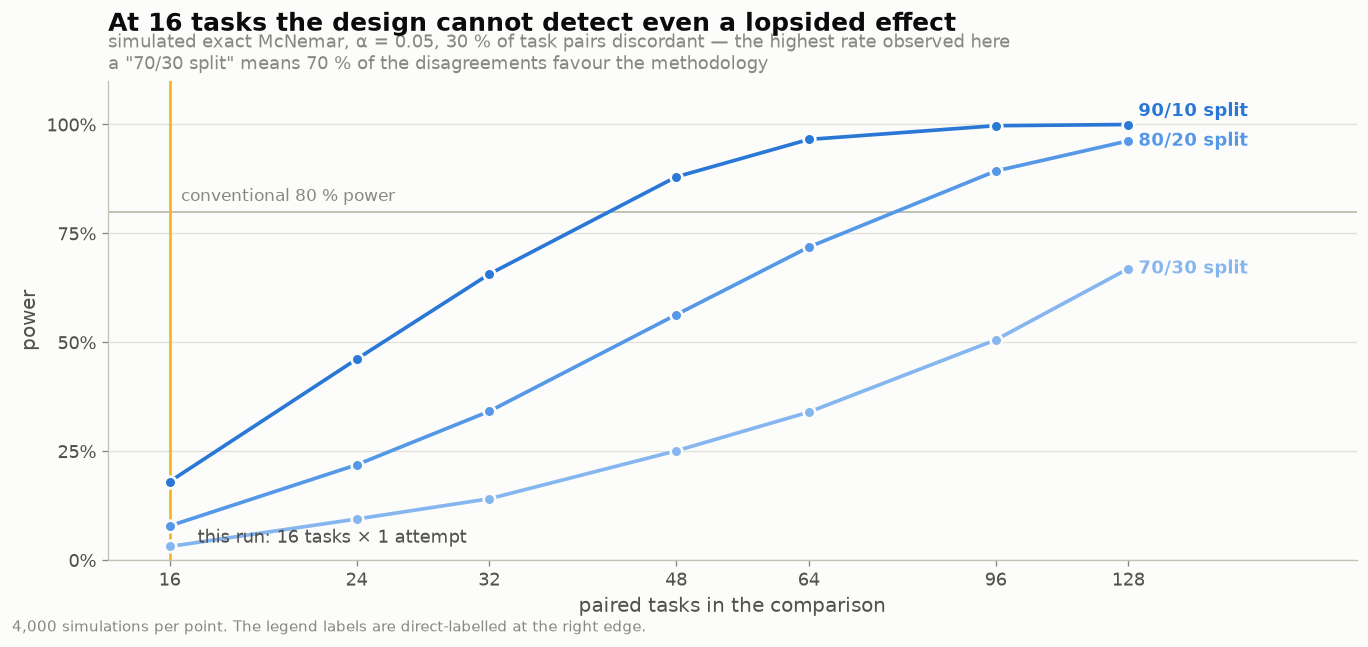

70/30 split                        tasks needed for 80% power: 192

80/20 split                        tasks needed for 80% power: 96


90/10 split                        tasks needed for 80% power: 48


In [8]:
rng = np.random.default_rng(20260828)


def mcnemar_power(n_tasks, p_disc, share_favouring_b, n_sim=4000, alpha=0.05):
    # Simulated power of the exact McNemar test for a paired binary A/B comparison.
    hits = 0
    for _ in range(n_sim):
        disc = rng.random(n_tasks) < p_disc
        n_disc = int(disc.sum())
        if n_disc == 0:
            continue
        only_b = int(rng.binomial(n_disc, share_favouring_b))
        if stats.binomtest(only_b, n_disc, 0.5).pvalue < alpha:
            hits += 1
    return hits / n_sim


P_DISC = 0.30  # observed: 5 of 16 task pairs discordant
grid = [16, 24, 32, 48, 64, 96, 128]
effects = [(0.70, "70/30 split"), (0.80, "80/20 split"), (0.90, "90/10 split")]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
endpoints = []
for (share, label), color in zip(effects, BLUE_RAMP[:3]):
    power = [mcnemar_power(n, P_DISC, share) for n in grid]
    ax.plot(grid, power, color=color, lw=2.2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
    endpoints.append((grid[-1], power[-1], label, color))
ax.axhline(0.8, color=AXIS, lw=1.2, zorder=2)
ax.text(16.4, 0.815, "conventional 80 % power", fontsize=10, color=MUTED, va="bottom")
ax.axvline(16, color=WARNING, lw=1.6, zorder=2)
ax.text(17, 0.03, "this run: 16 tasks × 1 attempt", fontsize=10.5, color=INK_2, va="bottom")
bare(ax)
ax.set_xscale("log")
ax.set_xticks(grid, [str(g) for g in grid])
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(14, 210)
ax.set_ylim(0, 1.10)
ax.set_yticks(np.arange(0, 1.01, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.01, 0.25)])
ax.set_xlabel("paired tasks in the comparison")
ax.set_ylabel("power")
spread_labels(ax, endpoints)
titled(ax, "At 16 tasks the design cannot detect even a lopsided effect",
       "simulated exact McNemar, α = 0.05, 30 % of task pairs discordant — the highest rate observed here\n"
       "a \"70/30 split\" means 70 % of the disagreements favour the methodology")
fig.tight_layout()
save(fig, "03-power", "4,000 simulations per point. The legend labels are direct-labelled at the right edge.")
plt.show()

for share, label in effects:
    need = next((n for n in [16, 24, 32, 48, 64, 96, 128, 192, 256]
                 if mcnemar_power(n, P_DISC, share, n_sim=2000) >= 0.8), None)
    print(f"{label:<34} tasks needed for 80% power: {need}")

## 3. What the methodology reliably does cost

The outcome is flat; the cost is not. This is the part of the run that *is* measured,
because cost is a continuous per-trial quantity rather than a rare binary event.

figures/04-overhead.png  figures/04-overhead.svg


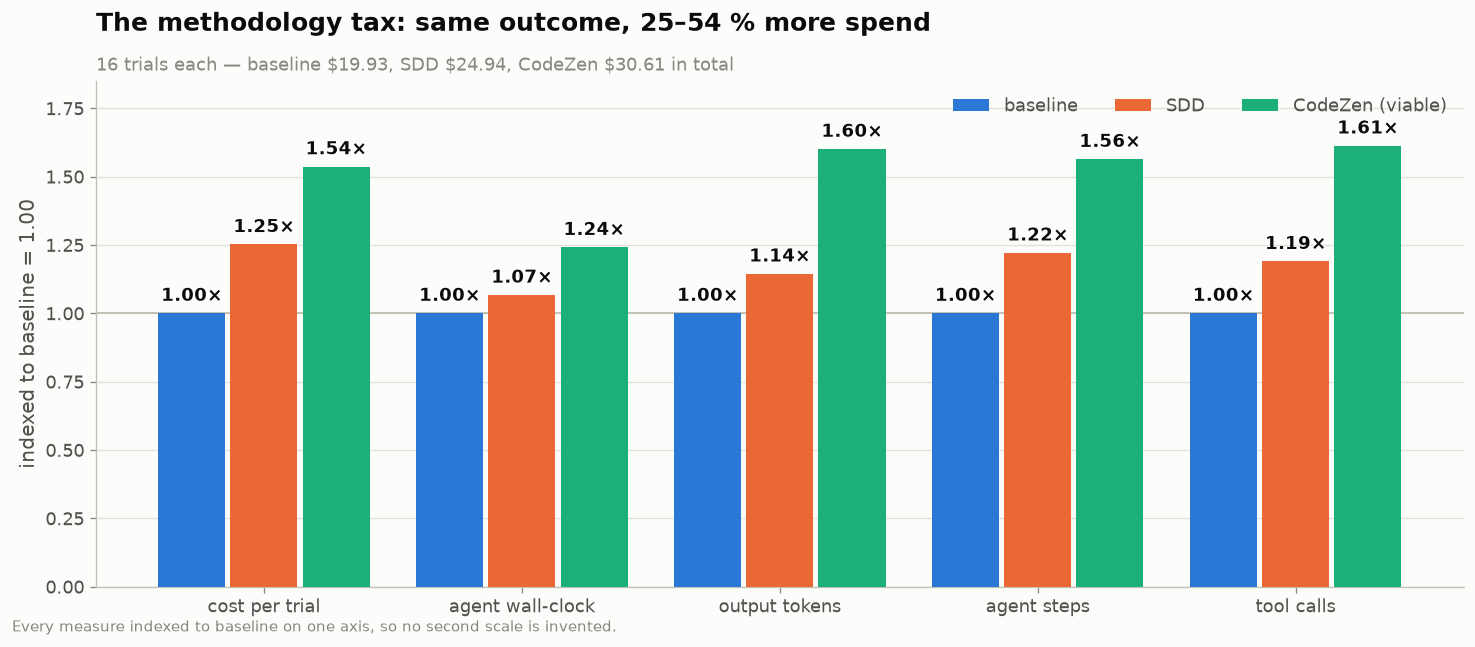

In [9]:
index = summary.loc[:, ["cost_per_trial", "agent_sec", "output_tokens", "steps", "tool_calls"]]
index = index.div(index.loc["baseline"])
metrics = [("cost_per_trial", "cost per trial"), ("agent_sec", "agent wall-clock"),
           ("output_tokens", "output tokens"), ("steps", "agent steps"),
           ("tool_calls", "tool calls")]

fig, ax = plt.subplots(figsize=(12.4, 5.4))
x = np.arange(len(metrics))
width = 0.26
for k, cond in enumerate(CONDITIONS):
    vals = [index.loc[cond, m] for m, _ in metrics]
    pos = x + (k - 1) * (width + 0.02)
    ax.bar(pos, vals, width=width, color=COLOR[cond], zorder=3, label=LABELS[cond])
    for xi, v in zip(pos, vals):
        ax.text(xi, v + 0.03, f"{v:.2f}×", ha="center", va="bottom", fontsize=10.5,
                color=INK, fontweight="bold")
ax.axhline(1.0, color=AXIS, lw=1.2, zorder=2)
bare(ax)
ax.set_xticks(x, [label for _, label in metrics])
ax.set_ylim(0, 1.85)
ax.set_ylabel("indexed to baseline = 1.00")
titled(ax, "The methodology tax: same outcome, 25–54 % more spend",
       f"16 trials each — baseline ${summary.loc['baseline','cost_usd']:.2f}, "
       f"SDD ${summary.loc['sdd','cost_usd']:.2f}, "
       f"CodeZen ${summary.loc['codezen-viable','cost_usd']:.2f} in total")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout()
save(fig, "04-overhead", "Every measure indexed to baseline on one axis, so no second scale is invented.")
plt.show()

### Per task, not on average

An index hides where the overhead comes from. Paired per-task costs show whether the tax
is spread across the set or carried by a few long tasks.

figures/05-cost-paired.png  figures/05-cost-paired.svg


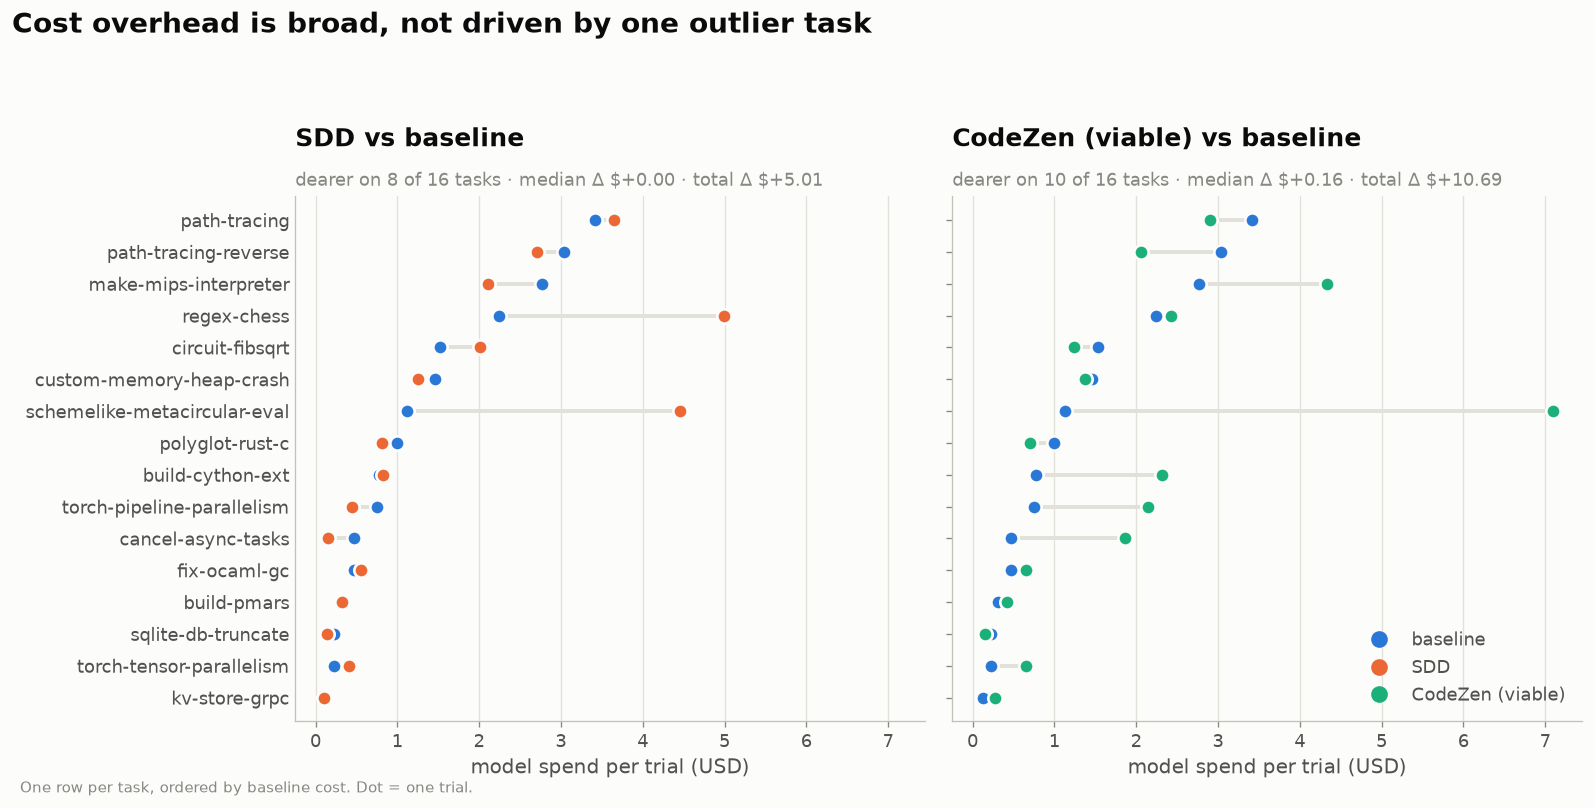

In [10]:
cost_pv = trials.pivot_table(index="task", columns="condition", values="cost_usd", observed=True)
cost_pv = cost_pv.loc[cost_pv["baseline"].sort_values().index]
y = np.arange(len(cost_pv))

fig, axes = plt.subplots(1, 2, figsize=(13.33, 6.2), sharey=True, sharex=True)
for ax, cond in zip(axes, ["sdd", "codezen-viable"]):
    for i, task in enumerate(cost_pv.index):
        b, t = cost_pv.loc[task, "baseline"], cost_pv.loc[task, cond]
        ax.plot([b, t], [i, i], color=GRID, lw=2.4, zorder=2, solid_capstyle="round")
        ax.scatter(b, i, s=74, color=COLOR["baseline"], zorder=3, edgecolors=SURFACE, linewidths=1.6)
        ax.scatter(t, i, s=74, color=COLOR[cond], zorder=4, edgecolors=SURFACE, linewidths=1.6)
    delta = (cost_pv[cond] - cost_pv["baseline"])
    titled(ax, f"{LABELS[cond]} vs baseline",
           f"dearer on {int((delta > 0).sum())} of 16 tasks · median Δ ${delta.median():+.2f} · "
           f"total Δ ${delta.sum():+.2f}")
    bare(ax, grid_axis="x")
    ax.set_xlabel("model spend per trial (USD)")
axes[0].set_yticks(y, cost_pv.index, fontsize=10.5)
axes[0].tick_params(axis="y", length=0)
handles = [Line2D([], [], marker="o", lw=0, markersize=9, color=COLOR[c], label=LABELS[c])
           for c in CONDITIONS]
axes[1].legend(handles=handles, loc="lower right", ncol=1)
fig.suptitle("Cost overhead is broad, not driven by one outlier task",
             x=0.005, ha="left", fontsize=17, fontweight="bold", color=INK, y=1.06)
fig.tight_layout()
save(fig, "05-cost-paired", "One row per task, ordered by baseline cost. Dot = one trial.")
plt.show()

## 4. The mechanism by which methodology can *hurt*: budget

Each task declares an agent time budget in its `task.toml`. Harbor kills the agent at that
budget and the trial is graded on whatever is on disk. So the interesting quantity is not
absolute duration but **fraction of the declared budget consumed** — a methodology that
adds a planning and review phase moves trials toward the wall, and past the wall a trial
is right-censored rather than failed on merit.

figures/06-budget.png  figures/06-budget.svg


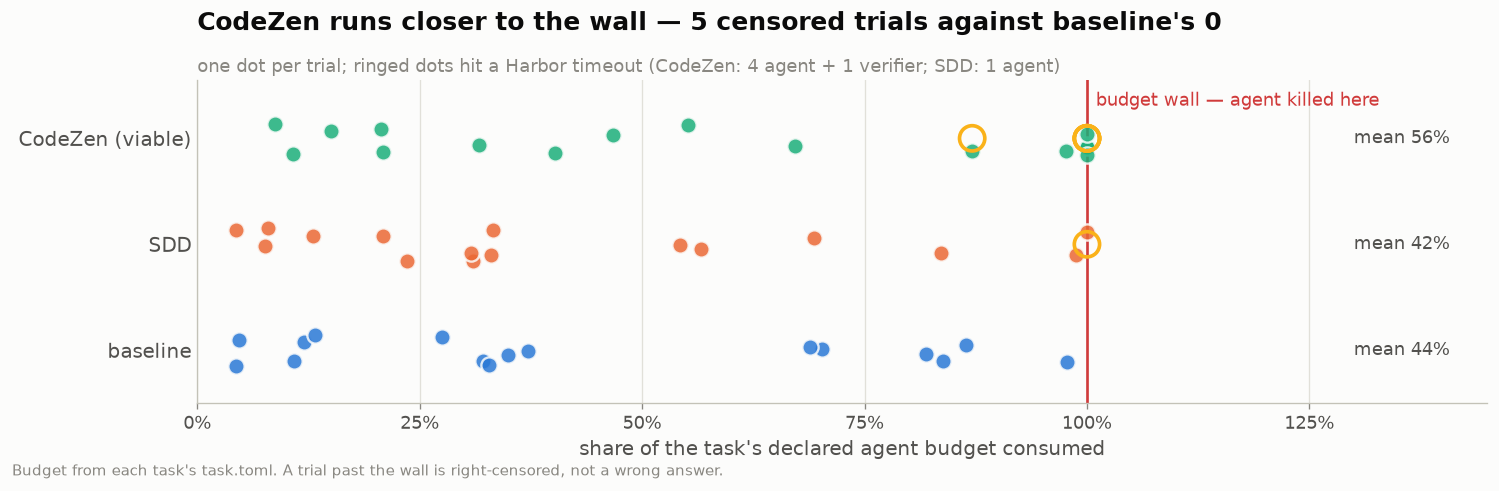

,mean_budget_used,trials_over_75pct,agent_timeouts,verifier_timeouts
condition,,,,
baseline,0.437,4,0,0
sdd,0.417,3,1,0
codezen-viable,0.564,6,4,1


In [11]:
fig, ax = plt.subplots(figsize=(12.6, 4.1))
for k, cond in enumerate(CONDITIONS):
    sub = trials[trials.condition == cond]
    yv = np.full(len(sub), k) + rng.uniform(-0.16, 0.16, len(sub))
    ax.scatter(sub.budget_used, yv, s=95, color=COLOR[cond], alpha=0.85, zorder=3,
               edgecolors=SURFACE, linewidths=1.4)
    to = sub[sub.agent_timeout | sub.verifier_timeout]
    ax.scatter(to.budget_used, np.full(len(to), k), s=230, facecolors="none",
               edgecolors=WARNING, linewidths=2.2, zorder=4)
    ax.text(1.30, k, f"mean {sub.budget_used.mean():.0%}", va="center", fontsize=11,
            color=INK_2)
ax.axvline(1.0, color=CRITICAL, lw=1.6, zorder=2)
ax.text(1.01, 2.44, "budget wall — agent killed here", fontsize=10.5, color=CRITICAL, va="top")
bare(ax, grid_axis="x")
ax.set_yticks(range(3), [LABELS[c] for c in CONDITIONS])
ax.tick_params(axis="y", length=0, labelsize=12)
ax.set_ylim(-0.5, 2.55)
ax.set_xlim(0, 1.45)
ax.set_xticks(np.arange(0, 1.26, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.26, 0.25)])
ax.set_xlabel("share of the task's declared agent budget consumed")
titled(ax, "CodeZen runs closer to the wall — 5 censored trials against baseline's 0",
       "one dot per trial; ringed dots hit a Harbor timeout (CodeZen: 4 agent + 1 verifier; SDD: 1 agent)")
fig.tight_layout()
save(fig, "06-budget", "Budget from each task's task.toml. A trial past the wall is right-censored, not a wrong answer.")
plt.show()

trials.groupby("condition", observed=True).agg(
    mean_budget_used=("budget_used", "mean"),
    trials_over_75pct=("budget_used", lambda s: int((s > 0.75).sum())),
    agent_timeouts=("agent_timeout", "sum"),
    verifier_timeouts=("verifier_timeout", "sum"),
).round(3)

## 5. What the agent actually did differently

The trajectory says what changed in behaviour even where the outcome did not. These are
per-trial means over 1,745 tool calls.

One caveat on the verification count: shell commands are bucketed by pattern, not parsed.
The `test` bucket catches test runners (`pytest`, `make test`, `cargo test`, `dune
runtest`, …) *and* the far commoner habit of compiling and running a self-written
`test_x.c` / `verify_y.py`. It still misses ad-hoc verification done inline in a heredoc,
so read it as a comparison between conditions on one corpus, not as an absolute count.
`src/prog16_extract.py` holds the patterns.

figures/07-behaviour.png  figures/07-behaviour.svg


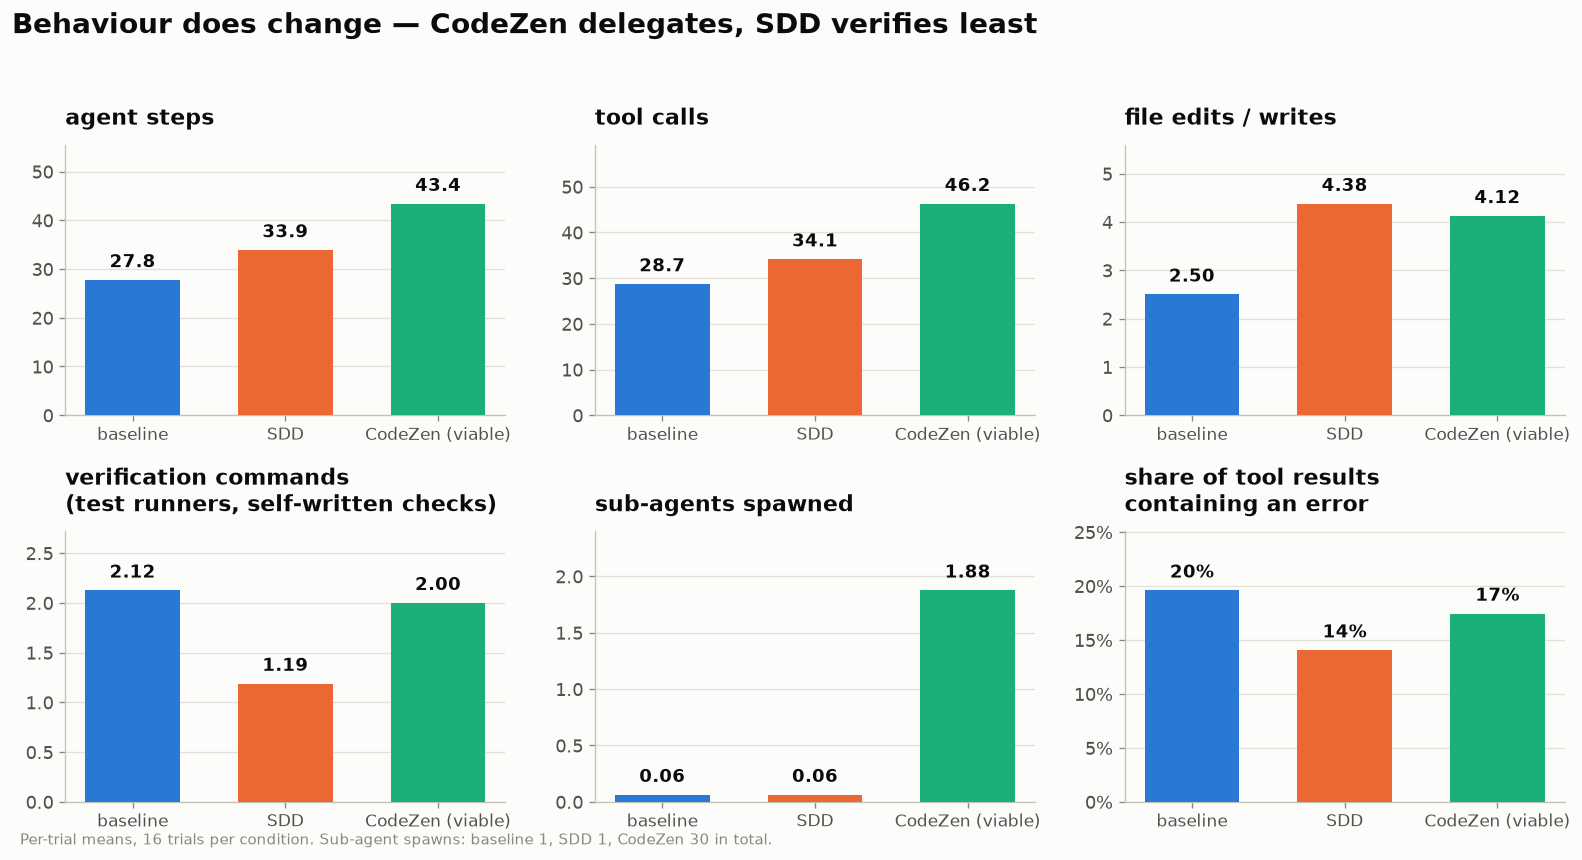

In [12]:
behaviour = [
    ("n_steps", "agent steps"),
    ("n_tool_calls", "tool calls"),
    ("n_edits_total", "file edits / writes"),
    ("bash_test", "verification commands\n(test runners, self-written checks)"),
    ("n_agent_spawns", "sub-agents spawned"),
    ("error_rate", "share of tool results\ncontaining an error"),
]
fig, axes = plt.subplots(2, 3, figsize=(13.33, 6.8))
for ax, (col, label) in zip(axes.ravel(), behaviour):
    vals = [trials.loc[trials.condition == c, col].mean() for c in CONDITIONS]
    for i, cond in enumerate(CONDITIONS):
        ax.bar(i, vals[i], width=0.62, color=COLOR[cond], zorder=3)
        if col == "error_rate":
            fmt = f"{vals[i]:.0%}"
        else:
            fmt = f"{vals[i]:.2f}" if max(vals) < 10 else f"{vals[i]:.1f}"
        ax.text(i, vals[i] + max(vals) * 0.04, fmt, ha="center", va="bottom", fontsize=11,
                color=INK, fontweight="bold")
    bare(ax)
    ax.set_xticks(range(3), [LABELS[c] for c in CONDITIONS], fontsize=10)
    ax.set_ylim(0, max(vals) * 1.28)
    if col == "error_rate":
        ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label, loc="left", fontsize=13)
fig.suptitle("Behaviour does change — CodeZen delegates, SDD verifies least",
             x=0.005, ha="left", fontsize=17, fontweight="bold", color=INK, y=1.03)
fig.tight_layout()
save(fig, "07-behaviour", "Per-trial means, 16 trials per condition. Sub-agent spawns: baseline 1, SDD 1, CodeZen 30 in total.")
plt.show()

figures/08-tool-mix.png  figures/08-tool-mix.svg


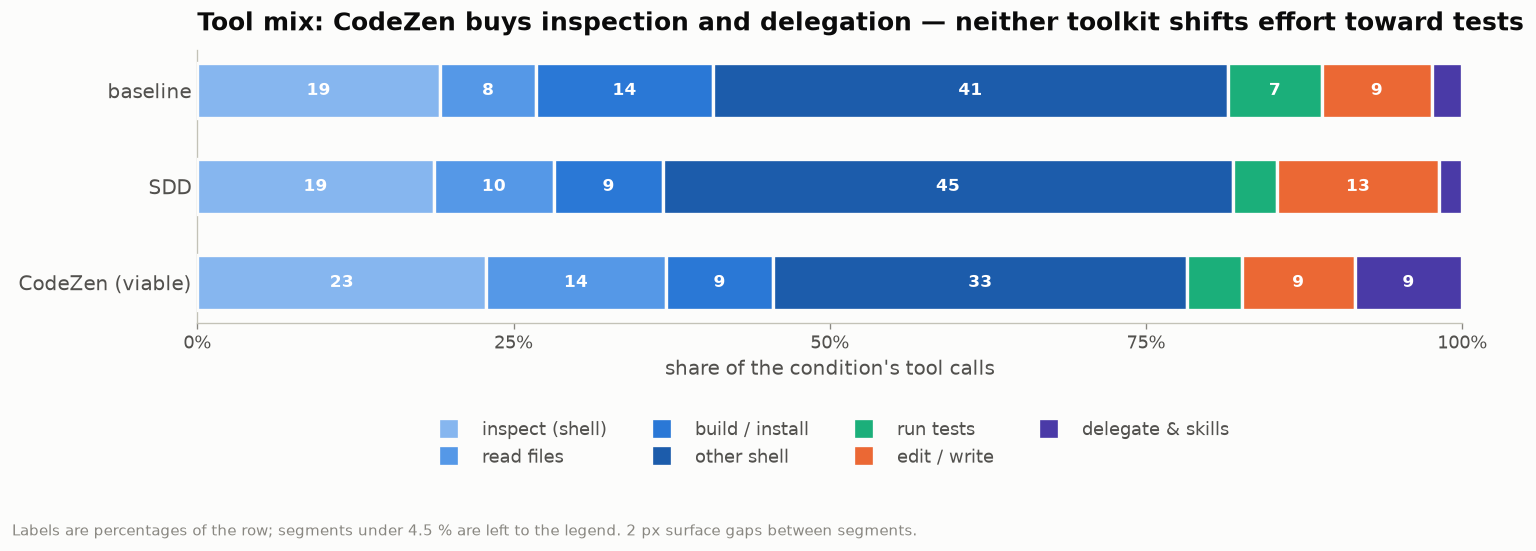

klass,build / install,delegate & skills,edit / write,inspect (shell),other shell,read files,run tests
condition,,,,,,,
baseline,13.9,2.4,8.7,19.2,40.7,7.6,7.4
sdd,8.6,1.8,12.8,18.7,45.1,9.5,3.5
codezen-viable,8.5,8.5,8.9,22.8,32.7,14.2,4.3


In [13]:
# Six classes, not fourteen: past about seven, adjacent colour classes blur. Read and
# web lookups fold into "inspect"; the orchestration tools fold into "delegate".
mix = calls.copy()
DELEGATE = {"Agent", "Skill", "TaskOutput", "TaskStop", "ListAgents", "ScheduleWakeup",
            "ToolSearch", "ReportFindings"}
mix["klass"] = np.select(
    [(mix.tool == "Bash") & (mix.bash_class == "inspect"),
     (mix.tool == "Bash") & (mix.bash_class == "build"),
     (mix.tool == "Bash") & (mix.bash_class == "test"),
     (mix.tool == "Bash"),
     mix.tool.isin(["Read", "WebFetch", "WebSearch"]),
     mix.tool.isin(["Edit", "Write", "NotebookEdit"]),
     mix.tool.isin(DELEGATE)],
    ["inspect (shell)", "build / install", "run tests", "other shell", "read files",
     "edit / write", "delegate & skills"], default="delegate & skills")
share = (mix.groupby(["condition", "klass"]).size().unstack(fill_value=0)
         .reindex(CONDITIONS).pipe(lambda d: d.div(d.sum(axis=1), axis=0)))
order = ["inspect (shell)", "read files", "build / install", "other shell", "run tests",
         "edit / write", "delegate & skills"]
order = [c for c in order if c in share.columns]
ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#1baf7a", "#eb6834", "#4a3aa7"]

fig, ax = plt.subplots(figsize=(12.6, 4.6))
left = np.zeros(len(CONDITIONS))
for col, color in zip(order, ramp):
    vals = share[col].values
    ax.barh(range(len(CONDITIONS)), vals, left=left, height=0.58, color=color, zorder=3,
            edgecolor=SURFACE, linewidth=2.0)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.045:
            ax.text(l + v / 2, i, f"{v*100:.0f}", ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")
    left += vals
bare(ax, grid_axis=None)
ax.set_yticks(range(len(CONDITIONS)), [LABELS[c] for c in CONDITIONS], fontsize=12)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.01, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.01, 0.25)])
ax.set_xlabel("share of the condition's tool calls")
ax.invert_yaxis()
ax.set_title("Tool mix: CodeZen buys inspection and delegation — neither toolkit shifts effort toward tests",
             loc="left")
ax.legend([Line2D([], [], marker="s", lw=0, markersize=10, color=c) for c in ramp[:len(order)]],
          order, loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=4)
fig.tight_layout()
save(fig, "08-tool-mix", "Labels are percentages of the row; segments under 4.5 % are left to the legend. 2 px surface gaps between segments.")
plt.show()
share.mul(100).round(1)

## 6. Adherence, corrected

`scripts/report.py` reports `Skill Tool Calls = 0` for all 48 trials. That is wrong. The
report counts the substring `"name": "Skill"`, but the ATIF trajectory schema names the
field `function_name`, so the counter can never fire. Reading `function_name` off the tool
calls finds **15 real `Skill` invocations**.

The same section's "Skills Invoked" column is too loose in the other direction: it
substring-matches skill names anywhere in agent-authored trajectory text, so an agent that
merely lists its skills directory scores as having used all of them. That is why
`codezen-viable` shows "all four skills" on trials where the strict count is one.

Both are fixed in `src/prog16_extract.py`; the funnel below uses the strict definition.

figures/09-adherence.png  figures/09-adherence.svg


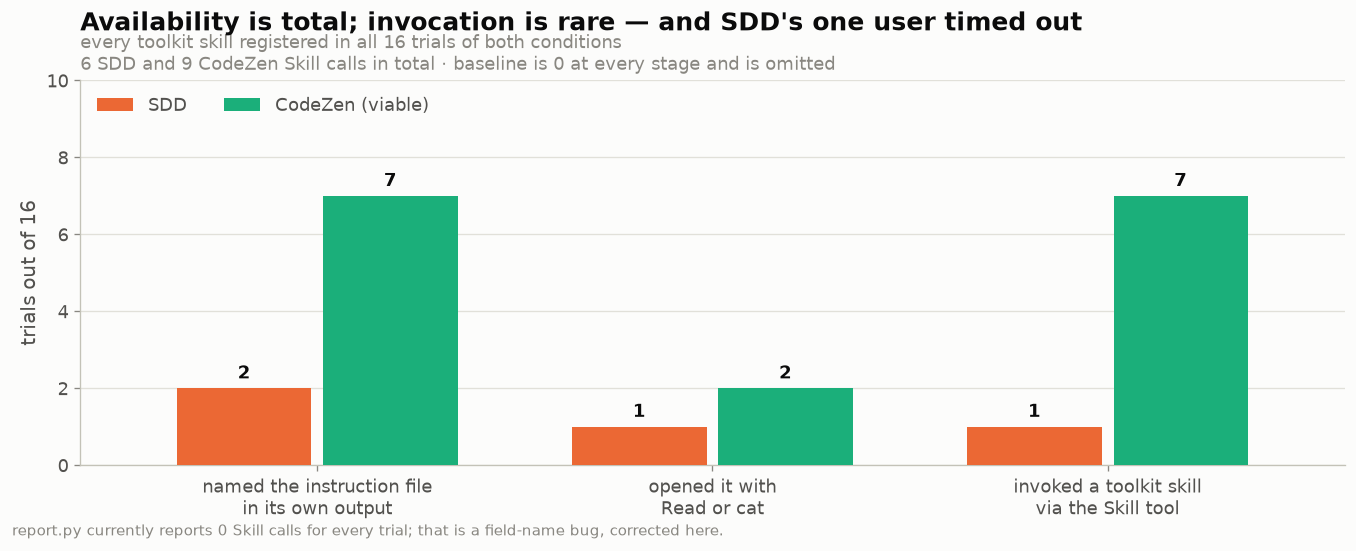

,baseline,SDD,CodeZen (viable)
skills shipped by the toolkit,0,7,4
registered by the CLI at startup,0,7,4
trials naming CLAUDE.md / AGENTS.md,0,2,7
trials opening an instruction file,0,1,2
trials invoking a toolkit skill,0,1,7
toolkit Skill tool calls in total,0,6,9


In [14]:
TOOLKITS = ["sdd", "codezen-viable"]
funnel = pd.DataFrame({
    "skills shipped by the toolkit": [trials.loc[trials.condition == c, "n_toolkit_skills"].max() for c in CONDITIONS],
    "registered by the CLI at startup": [trials.loc[trials.condition == c, "n_toolkit_skills_registered"].max() for c in CONDITIONS],
    "trials naming CLAUDE.md / AGENTS.md": [int(trials.loc[trials.condition == c, "config_markers"].notna().sum()) for c in CONDITIONS],
    "trials opening an instruction file": [int((trials.loc[trials.condition == c, "n_config_reads"] > 0).sum()) for c in CONDITIONS],
    "trials invoking a toolkit skill": [int((trials.loc[trials.condition == c, "n_toolkit_skill_calls"] > 0).sum()) for c in CONDITIONS],
    "toolkit Skill tool calls in total": [int(trials.loc[trials.condition == c, "n_toolkit_skill_calls"].sum()) for c in CONDITIONS],
}, index=[LABELS[c] for c in CONDITIONS]).T

# Every bar is a count of trials out of 16, so the axis carries one unit. The skill
# registration counts and the raw call totals belong in the subtitle, not on this axis.
stages = ["trials naming CLAUDE.md / AGENTS.md", "trials opening an instruction file",
          "trials invoking a toolkit skill"]
labels = ["named the instruction file\nin its own output",
          "opened it with\nRead or cat",
          "invoked a toolkit skill\nvia the Skill tool"]
fig, ax = plt.subplots(figsize=(11.4, 4.6))
x = np.arange(len(stages))
width = 0.34
for k, cond in enumerate(TOOLKITS):
    vals = [funnel.loc[s, LABELS[cond]] for s in stages]
    pos = x + (k - 0.5) * (width + 0.03)
    ax.bar(pos, vals, width=width, color=COLOR[cond], zorder=3, label=LABELS[cond])
    for xi, v in zip(pos, vals):
        ax.text(xi, v + 0.14, f"{v:.0f}", ha="center", va="bottom", fontsize=11, color=INK,
                fontweight="bold")
bare(ax)
ax.set_xticks(x, labels, fontsize=10.5)
ax.set_xlim(-0.6, len(stages) - 0.4)
ax.set_ylim(0, 10)
ax.set_yticks(range(0, 11, 2))
ax.set_ylabel("trials out of 16")
titled(ax, "Availability is total; invocation is rare — and SDD's one user timed out",
       "every toolkit skill registered in all 16 trials of both conditions\n"
       "6 SDD and 9 CodeZen Skill calls in total · baseline is 0 at every stage and is omitted")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
save(fig, "09-adherence", "report.py currently reports 0 Skill calls for every trial; that is a field-name bug, corrected here.")
plt.show()
funnel

In [15]:
used = trials[trials.n_toolkit_skill_calls > 0][
    ["task", "condition", "skill_call_sequence", "n_agent_spawns", "success",
     "cost_usd", "budget_used", "exception_type"]
].sort_values(["condition", "task"])
used.round(2)

,task,condition,skill_call_sequence,n_agent_spawns,success,cost_usd,budget_used,exception_type
44,schemelike-metacircular-eval,sdd,sdd-specify;sdd-clarify;sdd-plan;sdd-tasks;sdd...,0,False,4.46,1.00,AgentTimeoutError
16,build-cython-ext,codezen-viable,code-review,2,True,2.32,1.00,AgentTimeoutError
18,cancel-async-tasks,codezen-viable,noc-tdd;code-review,6,True,1.87,0.67,NaN
22,kv-store-grpc,codezen-viable,noc-tdd,0,True,0.27,0.11,NaN
23,make-mips-interpreter,codezen-viable,code-review,7,False,4.34,1.00,AgentTimeoutError
28,schemelike-metacircular-eval,codezen-viable,code-review;security-review,9,True,7.10,0.98,NaN
30,torch-pipeline-parallelism,codezen-viable,code-review,6,False,2.15,0.87,VerifierTimeoutError
31,torch-tensor-parallelism,codezen-viable,noc-tdd,0,False,0.66,0.40,NaN


Eight trials used a toolkit skill. Seven are CodeZen, and the pattern is that
`code-review` / `security-review` are invoked *after* the work — a review pass, not a
method for doing the work. `noc-tdd` is the only skill that drives implementation, used
three times. SDD's single skill-invoking trial ran the whole `sdd-specify → sdd-tasks`
chain and then hit the budget wall at 2,400 s with reward 0. That is the sharpest
observation in the run and it rests on one trial.

## 7. Where the time goes inside a trial

Cumulative tool calls against elapsed trial time, averaged over the condition's trials.
The shape says when a condition inspects, when it edits, and when it tests.

figures/10-effort-profile.png  figures/10-effort-profile.svg


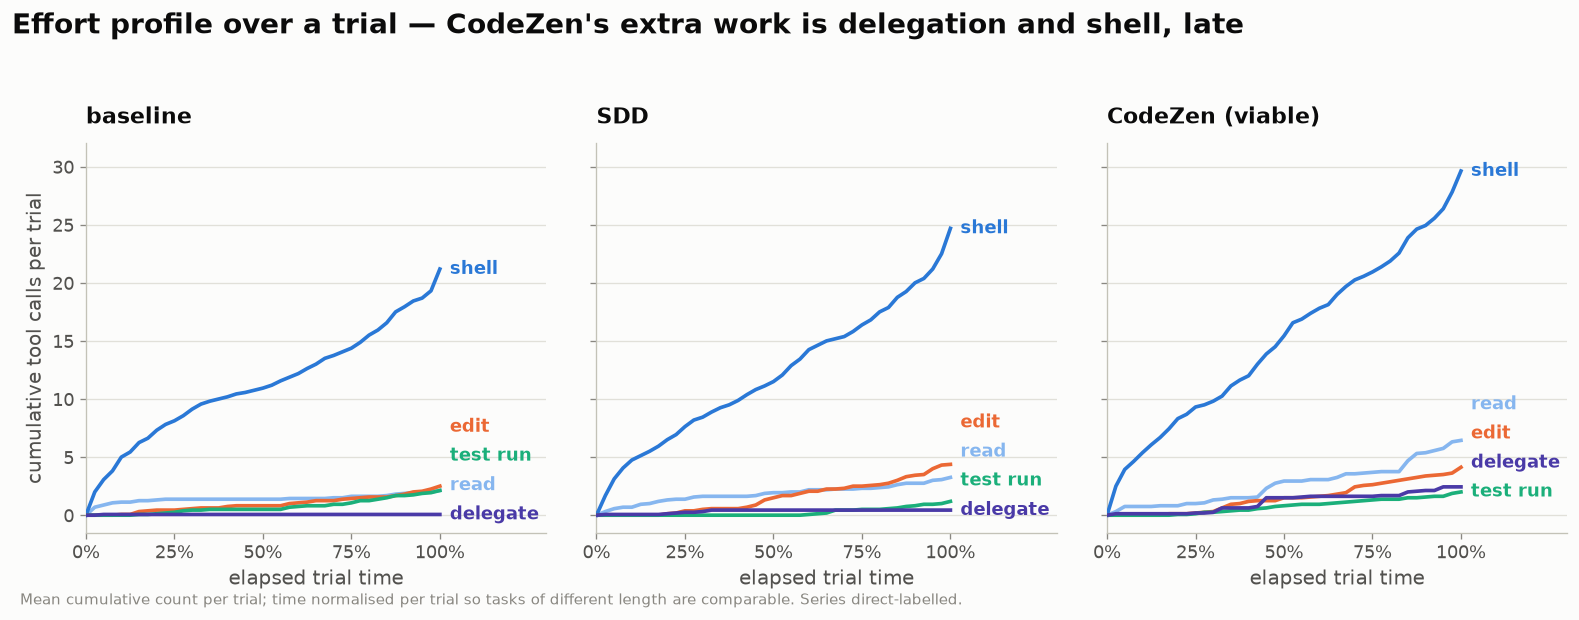

In [16]:
cal = calls.copy()
span = cal.groupby(["job_name"]).t_sec.transform("max")
cal["t_frac"] = np.where(span > 0, cal.t_sec / span, 0.0)
cal["klass"] = np.select(
    [cal.tool == "Bash", cal.tool.isin(["Edit", "Write"]), cal.tool == "Read",
     cal.tool.isin(["Agent", "Skill"])],
    ["shell", "edit", "read", "delegate"], default="other")
cal.loc[(cal.tool == "Bash") & (cal.bash_class == "test"), "klass"] = "test run"

grid = np.linspace(0, 1, 41)
klasses = ["read", "shell", "edit", "test run", "delegate"]
kcolors = dict(zip(klasses, ["#86b6ef", "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))

fig, axes = plt.subplots(1, 3, figsize=(13.33, 4.8), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    sub = cal[cal.condition == cond]
    n_jobs = sub.job_name.nunique()
    ends = []
    for klass in klasses:
        ks = sub[sub.klass == klass]
        curve = [(ks.t_frac <= g).sum() / n_jobs for g in grid]
        ax.plot(grid, curve, lw=2.2, color=kcolors[klass], zorder=3)
        ends.append((1.0, curve[-1], klass, kcolors[klass]))
    bare(ax)
    ax.set_xlim(0, 1.30)
    ax.set_ylim(-1.5, 32)
    spread_labels(ax, ends, min_gap_frac=0.075)
    ax.set_xticks(np.arange(0, 1.01, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.01, 0.25)])
    ax.set_xlabel("elapsed trial time")
    ax.set_title(LABELS[cond], loc="left", fontsize=13)
axes[0].set_ylabel("cumulative tool calls per trial")
fig.suptitle("Effort profile over a trial — CodeZen's extra work is delegation and shell, late",
             x=0.005, ha="left", fontsize=17, fontweight="bold", color=INK, y=1.04)
fig.tight_layout()
save(fig, "10-effort-profile", "Mean cumulative count per trial; time normalised per trial so tasks of different length are comparable. Series direct-labelled.")
plt.show()

## 8. Cost-effectiveness

The only defensible summary of this run: what one additional passing task would have cost.
With success rates equal, the marginal cost of methodology per additional success is
undefined or negative — the honest way to present it is cost per success achieved.

figures/11-cost-per-success.png  figures/11-cost-per-success.svg


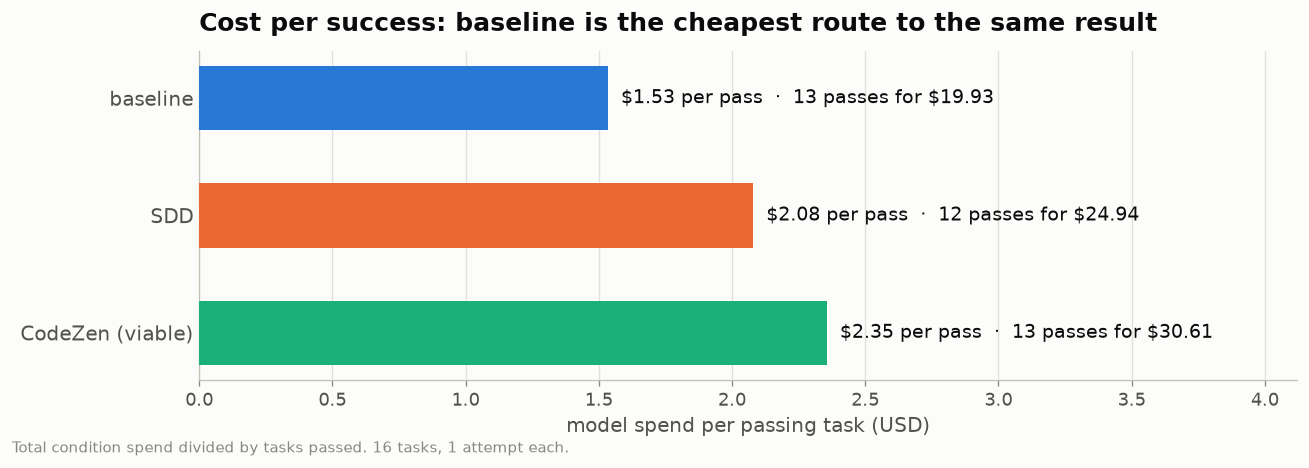

In [17]:
fig, ax = plt.subplots(figsize=(11.0, 3.9))
vals = [summary.loc[c, "cost_per_success"] for c in CONDITIONS]
for i, cond in enumerate(CONDITIONS):
    ax.barh(i, vals[i], height=0.55, color=COLOR[cond], zorder=3)
    ax.text(vals[i] + 0.05, i, f"${vals[i]:.2f} per pass  ·  "
            f"{int(summary.loc[cond,'successes'])} passes for ${summary.loc[cond,'cost_usd']:.2f}",
            va="center", fontsize=11.5, color=INK)
bare(ax, grid_axis="x")
ax.set_yticks(range(3), [LABELS[c] for c in CONDITIONS], fontsize=12)
ax.tick_params(axis="y", length=0)
ax.invert_yaxis()
ax.set_xlim(0, max(vals) * 1.75)
ax.set_xlabel("model spend per passing task (USD)")
ax.set_title("Cost per success: baseline is the cheapest route to the same result", loc="left")
fig.tight_layout()
save(fig, "11-cost-per-success", "Total condition spend divided by tasks passed. 16 tasks, 1 attempt each.")
plt.show()

## 9. Metric catalogue — what exists, what this notebook added, what to add next

### 9.1 Already reported by `scripts/report.py`

| Metric | Definition | Weakness this run exposed |
|---|---|---|
| success rate | share of trials with reward = 1.0 | binary, and 11 of 16 tasks are concordant → almost no information |
| mean reward | mean of the verifier's reward | identical to success rate here; the verifiers are pass/fail |
| avg duration | agent wall-clock | not comparable across tasks with different budgets |
| total cost | summed model spend | the one metric that separated conditions |
| skills available | names matched in the CLI startup log | true in 16/16 — a preflight restatement, not adherence |
| skills used | skill name matched anywhere in agent-authored text | false positives: an `ls` of the skills directory scores as usage |
| config referenced | `CLAUDE.md` / `AGENTS.md` named in agent text | cannot see the silent system-prompt load; measures talkativeness |

### 9.2 Derived here from data already on disk — no new trials

| Metric | How | Why it is worth having |
|---|---|---|
| **partial credit** | passed / total tests from `verifier/ctrf.json` | 183 graded outcomes instead of 48; catches "almost passed" |
| **test-level pass rate** | the same test outcomes pooled | ~4× the effective sample for the same spend |
| **budget utilisation** | `agent_sec` / `task.toml` agent budget | task-normalised time; the timeout mechanism becomes visible |
| **censoring flag** | `AgentTimeoutError` / `VerifierTimeoutError` | separates "wrong" from "ran out of clock" — different findings |
| **strict skill invocation** | `Skill` tool calls whose name the variant installed | the actual adherence measure; fixes a report bug |
| **skill call sequence** | ordered skill names per trial | distinguishes method-driving (`noc-tdd`) from post-hoc review |
| **sub-agent spawns** | `Agent` tool calls | CodeZen's real behavioural signature: 30 vs 1 |
| **tool mix** | tool calls bucketed, Bash sub-classified | where the extra spend went |
| **test-command count** | Bash commands matching a test-runner pattern | *self-verification effort*, independent of the verifier |
| **error rate** | share of tool results carrying an error marker | friction; a proxy for rework |
| **files touched, edits per file** | Edit/Write targets | churn vs. focus |
| **time to first edit, explore share** | first Edit/Write vs trajectory start | how much of a trial is front-loaded planning |
| **thinking share** | thinking tokens / output tokens | how much of the extra spend is reasoning vs. output |
| **cache hit ratio** | cache / input tokens | 95 % in every condition — no cache confound between conditions |
| **phase split** | env setup / agent setup / agent / verifier timestamps | keeps infrastructure time out of the agent comparison |
| **wrote-own-test flag** | an Edit/Write to a test-shaped path | SDD did this 0 times; baseline 2, CodeZen 4 |
| **cost per success** | condition spend / passes | the decision-relevant framing |
| **discordant-pair count** | paired outcome disagreements | the design's real sample size |

### 9.3 Worth instrumenting before the next run

Ordered by value per unit of effort.

| Proposed metric | Definition | What it would settle | Cost to add |
|---|---|---|---|
| **Reward trajectory / snapshot grading** | run the verifier against the workdir at intervals (or on the agent's final state at k checkpoints) | turns a censored trial into a curve: was CodeZen *behind* at the wall, or ahead and unlucky? | Harbor task change: a snapshot hook; moderate |
| **Time-to-first-passing-test** | timestamp of the first agent-run test command whose output shows a pass | a real speed metric that survives the ceiling — most tasks pass, so *when* differs even when *whether* does not | free from trajectories once tool-result parsing is added |
| **Requirement-level scoring** | map each enumerated requirement in `instruction.md` to the verifier tests that check it | per-requirement credit; directly tests the "spec-dense" claim | one-off manual mapping per task |
| **Instruction-compliance rate** | did the agent do what its own `CLAUDE.md` told it to (e.g. write a spec file first)? Detect the artefacts the method prescribes | separates "the method was available" from "the method was followed" — the gap this whole run turns on | per-toolkit artefact list; cheap |
| **Rework ratio** | edits to a file after that file's first successful test run | quantifies churn the current edit count cannot distinguish from progress | free from trajectories |
| **Recovery rate** | share of error observations followed within k steps by a non-error result on the same target | resilience, which is what RCA-style skills claim | free from trajectories |
| **Token efficiency per requirement** | output tokens / requirements satisfied | normalises spend by delivered scope rather than by trial | needs requirement-level scoring |
| **Solution quality beyond pass** | run a fixed linter/complexity/coverage pass over the final workdir | the methodologies claim quality, and a pass/fail verifier cannot see it | verifier-side addition; moderate |
| **Verifier flakiness control** | re-run the verifier k times on the same final state | separates a flaky verifier from a real fail (`torch-tensor-parallelism` failed in all three) | cheap, no model tokens |
| **Oracle-normalised difficulty** | per-task oracle pass and `nop` pass, recorded alongside | lets a concordant task be dropped *a priori* rather than discovered afterwards | one oracle run per task, no model tokens |
| **Adherence dose–response** | strict skill-invocation count vs outcome, pooled across runs | if adherence is this rare, the effect estimate needs it as a covariate, not as a rate | free, but needs more trials |

## 10. What this run supports, and what it does not

**Supported.**

1. The pipeline works end to end at 16-task scale, with no payload collisions and no build
   failures. 47 of 48 trials produced a reward; the 48th (`torch-pipeline-parallelism` under
   CodeZen) lost its verifier to a timeout, so it has neither a reward nor per-test detail
   and counts as a non-success throughout.
2. Methodology conditions cost 25 % (SDD) and 54 % (CodeZen) more than baseline for the
   same measured outcome; CodeZen also takes 1.24× the wall-clock and 1.56× the steps
   (the only paired comparison significant at p < 0.05).
3. Methodology consumes budget headroom and therefore raises censoring risk: 5 CodeZen
   trials and 1 SDD trial hit a Harbor timeout, against 0 for baseline.
4. Availability is not adherence. All toolkit skills registered in all 32 toolkit trials;
   a toolkit skill was actually invoked in 8, and mostly as a post-hoc review pass.

**Not supported.**

1. Any claim about which methodology produces better outcomes. 11 of 16 tasks are
   concordant, no pairwise McNemar is anywhere near significance, and the simulated power
   at this design is under 20 % even for a lopsided effect.
2. Any claim about `codezen-viable` versus `codezen-full` — only the probe ran the full
   condition.
3. Anything per-condition about variance: this run recorded **1 attempt per cell**, so
   there is no within-cell replicate at all.

**Design changes that follow, cheapest first.**

| Change | Why | Cost |
|---|---|---|
| Report partial credit and test-level pass rate as headline metrics | ~4× the graded outcomes from the same trials | free |
| Fix the `Skill`-call counter and tighten "skills used" in `report.py` | the current columns are wrong in both directions | free |
| Drop or replace the 10 all-pass tasks; keep them only as a floor check | they consume 60 % of the spend ($45.23 of $75.49) and carry no information | free, and it *reduces* cost |
| Re-run the verifier on the final state of the 3 all-fail / flaky trials | separates verifier flake from real failure | ~$0 |
| Raise `--attempts` to 3 on a smaller, discriminating task set | replicates within a cell; enables any variance claim | same total spend as this run |
| Report timeouts as censored, not as failures | a censored trial is a different finding from a wrong answer | free |
| Add the instruction-compliance and time-to-first-passing-test metrics | measures whether the method was followed, and speed under a ceiling | small code change |

In [18]:
# Machine-readable exports for downstream slides and tables.
out = ANALYSIS_DIR / "data"
summary.round(4).to_csv(out / "prog16_condition_summary.csv")
paired.round(4).to_csv(out / "prog16_paired_tests.csv", index=False)
outcome.astype(int).to_csv(out / "prog16_outcome_matrix.csv")
funnel.to_csv(out / "prog16_adherence_funnel.csv")
share.round(4).to_csv(out / "prog16_tool_mix.csv")
print("wrote:", *sorted(p.name for p in out.glob("prog16_*.csv")), sep="\n  ")
print()
print("figures:", *sorted(p.name for p in FIG_DIR.glob("*.png")), sep="\n  ")

wrote:
  prog16_adherence_funnel.csv
  prog16_condition_summary.csv
  prog16_outcome_matrix.csv
  prog16_paired_tests.csv
  prog16_steps.csv
  prog16_tests.csv
  prog16_tool_calls.csv
  prog16_tool_mix.csv
  prog16_trials.csv

figures:
  01-outcome.png
  02-outcome-matrix.png
  03-power.png
  04-overhead.png
  05-cost-paired.png
  06-budget.png
  07-behaviour.png
  08-tool-mix.png
  09-adherence.png
  10-effort-profile.png
  11-cost-per-success.png
